In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import pandas as pd

# Read the CSV file with a comma delimiter
df = pd.read_csv('/content/drive/MyDrive/PRAKTIKUM/praktikum11/data/Iris.csv')

# cetak header data (5 baris data) dari file
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [6]:
df.info ()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [8]:
# Periksa jumlah nilai kosong (missing values) di setiap kolom
df.isnull().sum()



,0
Id,0
SepalLengthCm,0
SepalWidthCm,0
PetalLengthCm,0
PetalWidthCm,0
Species,0


In [9]:
# Periksa jumlah baris yang terduplikasi (duplicated rows)
df.duplicated().sum()

np.int64(0)

In [13]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [14]:
df["Species"].unique()

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

In [15]:
df["Species"].value_counts()

,count
Species,
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


In [16]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["SpeciesEncoded"] = le.fit_transform(df["Species"])

In [17]:
# Fitur untuk clustering
X = df.drop(["Species", "SpeciesEncoded", "Id"], axis=1)

In [30]:
from sklearn.preprocessing import StandardScaler

# 1. Initialize the Scaler
scaler = StandardScaler()

# 2. Select Features
# It selects the 4 numeric columns from the Iris dataset
X = df[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']]

# 3. Apply the Scaling
# fit_transform() calculates the mean and standard deviation,
# then transforms the data in one step.
X = scaler.fit_transform(X)

# 4. Show the first 5 rows
X[:5]

array([[-0.90068117,  1.03205722, -1.3412724 , -1.31297673],
       [-1.14301691, -0.1249576 , -1.3412724 , -1.31297673],
       [-1.38535265,  0.33784833, -1.39813811, -1.31297673],
       [-1.50652052,  0.10644536, -1.2844067 , -1.31297673],
       [-1.02184904,  1.26346019, -1.3412724 , -1.31297673]])

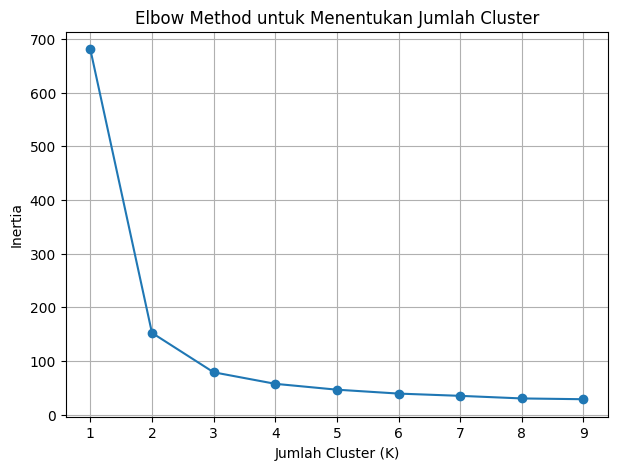

In [31]:
kmeans.fit(X)

KMeans(n_clusters=3, random_state=42)

In [32]:
labels = kmeans.predict(X)

In [33]:
df["cluster"] = labels

In [34]:
print("cluster ditemukan:",df["cluster"].unique())

cluster ditemukan: [1 2 0]


In [19]:
from sklearn.cluster import KMeans

# 1. Inisialisasi Model K-Means
kmeans = KMeans(
    n_clusters=3,        # Menggunakan K=3 berdasarkan jumlah spesies (atau hasil Elbow Method)
    init="k-means++",    # Metode untuk pemilihan pusat cluster awal yang lebih baik
    random_state=42,     # Untuk hasil yang konsisten
    n_init='auto'        # Ditambahkan untuk kompatibilitas versi sklearn terbaru
)



# 3. Menampilkan Hasil Cluster yang Ditemukan
print("Cluster ditemukan:", df["Cluster"].unique())

Cluster ditemukan: [1 0 2]


In [20]:
# 2. Melatih Model dan Memprediksi Cluster
df["Cluster"] = kmeans.fit_predict(X)

In [21]:
# 3. Menampilkan Hasil Cluster yang Ditemukan
print("Cluster ditemukan:", df["Cluster"].unique())

Cluster ditemukan: [1 0 2]


In [22]:
from sklearn.metrics import silhouette_score

# Menghitung Silhouette Score
sil_score = silhouette_score(X, df["Cluster"])

# Mencetak Hasil
print("\n===== SILHOUETTE SCORE =====")
print("Silhouette Score:", sil_score)


===== SILHOUETTE SCORE =====
Silhouette Score: 0.5509643746707443


In [36]:
x = df[["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]]

scaler = StandardScaler()
x = scaler.fit_transform(x)
x[:5]

array([[-0.90068117,  1.03205722, -1.3412724 , -1.31297673],
       [-1.14301691, -0.1249576 , -1.3412724 , -1.31297673],
       [-1.38535265,  0.33784833, -1.39813811, -1.31297673],
       [-1.50652052,  0.10644536, -1.2844067 , -1.31297673],
       [-1.02184904,  1.26346019, -1.3412724 , -1.31297673]])

In [37]:
x = df[["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]]

scaler = StandardScaler()
x = scaler.fit_transform(x)
x[:5]

array([[-0.90068117,  1.03205722, -1.3412724 , -1.31297673],
       [-1.14301691, -0.1249576 , -1.3412724 , -1.31297673],
       [-1.38535265,  0.33784833, -1.39813811, -1.31297673],
       [-1.50652052,  0.10644536, -1.2844067 , -1.31297673],
       [-1.02184904,  1.26346019, -1.3412724 , -1.31297673]])

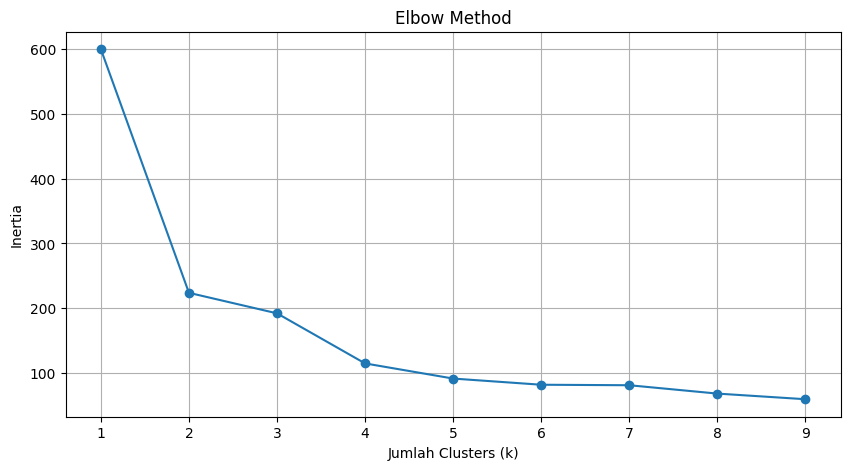

In [38]:
inertia_list = []
x_range = range(1, 10)

for k in x_range:
  km = KMeans(n_clusters=k, random_state=42)
  km.fit(x)
  inertia_list.append(km.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(x_range, inertia_list, marker='o')
plt.xlabel('Jumlah Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.grid(True)
plt.show()

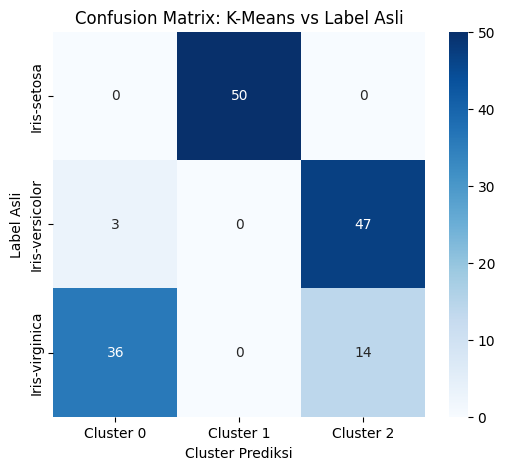

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Atur ukuran figure
plt.figure(figsize=(6,5))

# Buat heatmap dari Confusion Matrix (cm)
sns.heatmap(
    cm,                              # Data Confusion Matrix (dari langkah sebelumnya)
    annot=True,                      # Tampilkan nilai numerik di setiap sel
    fmt='d',                         # Format nilai sebagai integer (desimal)
    cmap='Blues',                    # Gunakan skema warna 'Blues'
    xticklabels=["Cluster 0", "Cluster 1", "Cluster 2"], # Label untuk sumbu X (Prediksi K-Means)
    yticklabels=le.classes_          # Label untuk sumbu Y (Label Asli/Spesies)
)

# Atur Judul dan Label Sumbu
plt.title("Confusion Matrix: K-Means vs Label Asli")
plt.xlabel("Cluster Prediksi")
plt.ylabel("Label Asli")

# Tampilkan plot
plt.show()

In [39]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(x)

Labels = kmeans.predict(x)

df["Cluster"] = Labels

print("Cluster ditemukan", df["Cluster"].unique())

Cluster ditemukan [1 2 0]


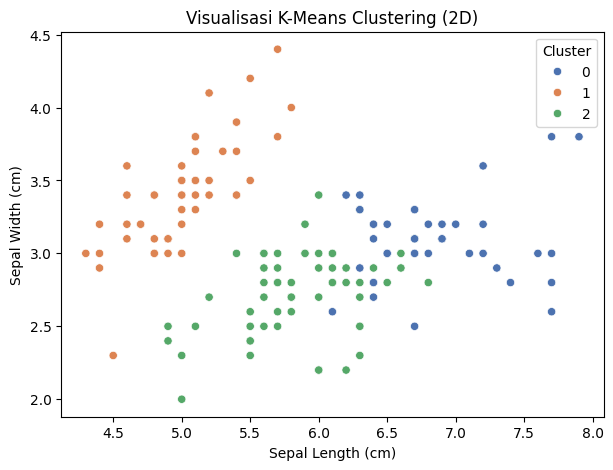

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Atur ukuran figure
plt.figure(figsize=(7,5))

# Buat Scatter Plot
sns.scatterplot(
    x=df["SepalLengthCm"],    # Sumbu X: Panjang Sepal
    y=df["SepalWidthCm"],     # Sumbu Y: Lebar Sepal
    hue=df["Cluster"],        # Warna titik berdasarkan Cluster yang ditemukan K-Means
    palette="deep"            # Skema warna
)

# Atur Judul dan Label Sumbu
plt.title("Visualisasi K-Means Clustering (2D)")
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Sepal Width (cm)")

# Tampilkan plot
plt.show()

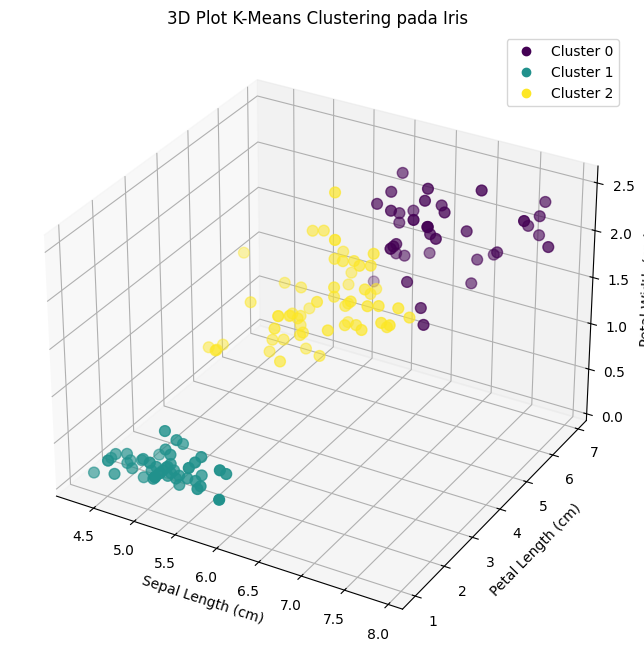

In [26]:
import matplotlib.pyplot as plt
# (Asumsikan Anda sudah memiliki import untuk numpy jika diperlukan, tapi Matplotlib cukup)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Membuat 3D Scatter Plot
# Sumbu X: Sepal Length, Sumbu Y: Petal Length, Sumbu Z: Petal Width
scatter = ax.scatter(
    df["SepalLengthCm"],
    df["PetalLengthCm"],
    df["PetalWidthCm"],
    c=df["Cluster"],  # Warna titik berdasarkan Cluster
    s=60              # Ukuran titik
)

# Menetapkan Label dan Judul Sumbu
ax.set_title("3D Plot K-Means Clustering pada Iris")
ax.set_xlabel("Sepal Length (cm)")
ax.set_ylabel("Petal Length (cm)")
ax.set_zlabel("Petal Width (cm)")

# Menambahkan Legend (Legenda) untuk Cluster
# Membuat label kustom: ["Cluster 0", "Cluster 1", "Cluster 2"]
legend_labels = [f"Cluster {i}" for i in range(3)]
ax.legend(handles=scatter.legend_elements()[0], labels=legend_labels)

plt.show()

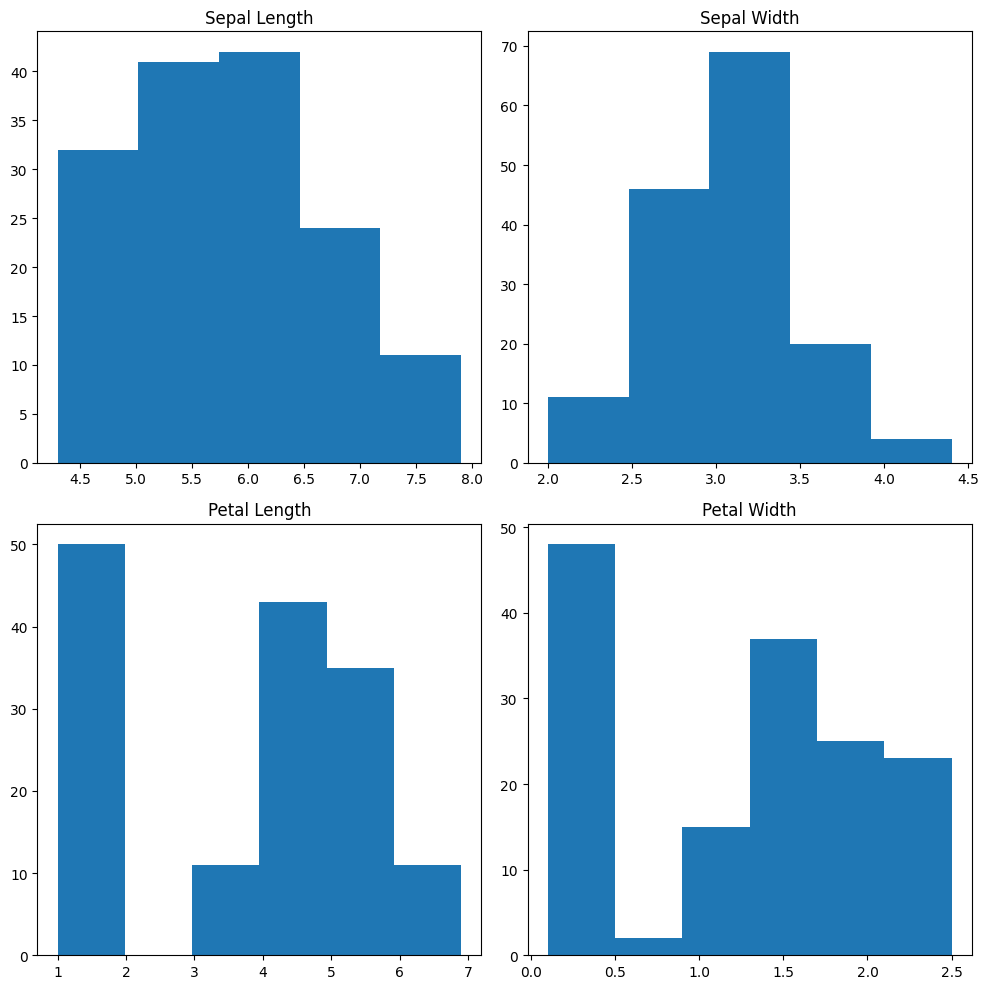

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

# Histogram 1: Sepal Length
axes[0, 0].set_title("Sepal Length")
axes[0, 0].hist(X['SepalLengthCm'], bins=5)

# Histogram 2: Sepal Width
axes[0, 1].set_title("Sepal Width")
axes[0, 1].hist(X['SepalWidthCm'], bins=5)

# Histogram 3: Petal Length
axes[1, 0].set_title("Petal Length")
axes[1, 0].hist(X['PetalLengthCm'], bins=6)

# Histogram 4: Petal Width
axes[1, 1].set_title("Petal Width")
axes[1, 1].hist(X['PetalWidthCm'], bins=6)

plt.tight_layout()
plt.show()

In [28]:
from sklearn.preprocessing import StandardScaler

# 1. Initialize the Scaler
scaler = StandardScaler()

# 2. Select Features
# It selects the 4 numeric columns from the Iris dataset
X = df[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']]

# 3. Apply the Scaling
# fit_transform() calculates the mean and standard deviation,
# then transforms the data in one step.
X = scaler.fit_transform(X)

# 4. Show the first 5 rows
X[:5]

array([[-0.90068117,  1.03205722, -1.3412724 , -1.31297673],
       [-1.14301691, -0.1249576 , -1.3412724 , -1.31297673],
       [-1.38535265,  0.33784833, -1.39813811, -1.31297673],
       [-1.50652052,  0.10644536, -1.2844067 , -1.31297673],
       [-1.02184904,  1.26346019, -1.3412724 , -1.31297673]])